In [10]:
# Import OpenCV for image processing operations
import cv2

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for displaying images inside the notebook
import matplotlib.pyplot as plt

In [11]:
# Import utilities for webcam access in Google Colab
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

# Function to capture an image using the webcam
def take_photo(filename='photo.jpg', quality=0.8):

  # JavaScript code to access the webcam and capture an image
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      // Create video element to stream webcam feed
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      // Draw captured frame onto canvas
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Stop webcam stream after capture
      stream.getVideoTracks()[0].stop();
      div.remove();

      // Return captured image as base64 encoded JPEG
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
 # Display JavaScript interface in notebook
  display(js)

  # Execute JavaScript function and retrieve image data
  data = eval_js('takePhoto({})'.format(quality))

  # Decode base64 image data into binary format
  binary = b64decode(data.split(',')[1])

  # Save captured image to local file
  with open(filename, 'wb') as f:
    f.write(binary)

  return filename

<IPython.core.display.Javascript object>

Saved to photo.jpg


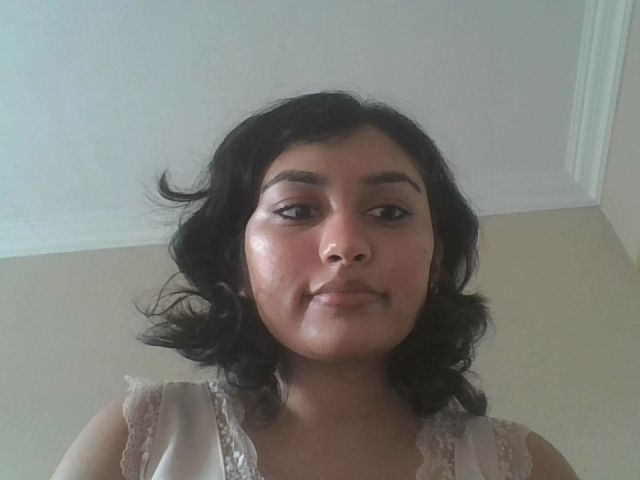

In [12]:
# Import utility to display images inside the notebook
from IPython.display import Image

try:
    # Call webcam capture function
    filename = take_photo()

    # Confirm image was saved successfully
    print('Saved to {}'.format(filename))

    # Show the image which was just taken.
    display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

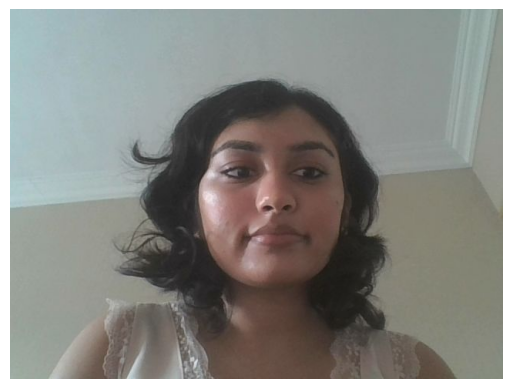

In [13]:
# Function to load the captured image from file
def load_captured_image(path):
    # Read image using OpenCV
    img = cv2.imread(path)

    # Convert BGR to RGB for correct visualization
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img


# Load the image captured from Task 1
img = load_captured_image(filename)

# Display the original captured image
plt.imshow(img)
plt.axis("off")  # Hide axis for cleaner visualization

In [14]:
# Resize the image to ensure LEGO grid does not exceed 100x100
# This satisfies the assignment constraint for Task 2
def resize_for_lego(img, max_size=100):
    h, w, _ = img.shape

    # Compute scaling factor while preserving aspect ratio
    scale = min(max_size / h, max_size / w, 1.0)

    new_size = (int(w * scale), int(h * scale))

    # Resize using area interpolation for downscaling
    return cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)


# Convert RGB image to grayscale (Task 2 requirement)
def to_grayscale(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


# Quantize grayscale image into exactly three tones:
# black, gray, and white
# This enforces the three-color constraint in Task 2
def quantize_3_colors(gray):
    quantized = np.zeros_like(gray)

    # Define custom threshold ranges
    quantized[gray < 100] = 0
    quantized[(gray >= 100) & (gray < 180)] = 128
    quantized[gray >= 180] = 255

    return quantized


# Convert quantized grayscale values to RGB LEGO colors
# Each pixel corresponds to a 1x1 LEGO brick in Task 2
def render_lego(quantized):
    h, w = quantized.shape

    # Create 3-channel RGB image
    lego_rgb = np.zeros((h, w, 3), dtype=np.uint8)

    # Map intensity levels to LEGO brick colors
    lego_rgb[quantized == 0] = [0, 0, 0]            # Black
    lego_rgb[quantized == 128] = [160, 160, 160]    # Gray
    lego_rgb[quantized == 255] = [255, 255, 255]    # White

    return lego_rgb


# Upscale LEGO grid so each pixel becomes a visible brick
# Uses nearest-neighbor interpolation to preserve block structure
def upscale_lego(lego_rgb, brick_size=10):
    return cv2.resize(
        lego_rgb,
        (lego_rgb.shape[1] * brick_size,
         lego_rgb.shape[0] * brick_size),
        interpolation=cv2.INTER_NEAREST
    )


# Add LEGO stud styling -> This enhances visual realism but does not change brick count
def render_lego_style(lego_rgb, brick_size=10):
    h, w, _ = lego_rgb.shape
    styled = lego_rgb.copy()

    for y in range(0, h, brick_size):
        for x in range(0, w, brick_size):

            # Draw darker rectangular border around each brick
            cv2.rectangle(
                styled,
                (x, y),
                (x + brick_size - 1, y + brick_size - 1),
                (100, 100, 100),
                1
            )

            # Compute center for circular stud
            center = (x + brick_size // 2, y + brick_size // 2)
            radius = brick_size // 3

            # Draw darker base circle
            cv2.circle(styled, center, radius, (80, 80, 80), -1)

            # Add highlight for 3D lighting effect
            highlight_center = (center[0] - radius//3, center[1] - radius//3)
            cv2.circle(styled, highlight_center, radius//2, (200, 200, 200), -1)

            # Add subtle outer ring for detail
            cv2.circle(styled, center, radius, (150, 150, 150), 1)

    return styled


# Import KMeans for potential color clustering experimentation
# Used during development for testing adaptive color quantization
from sklearn.cluster import KMeans


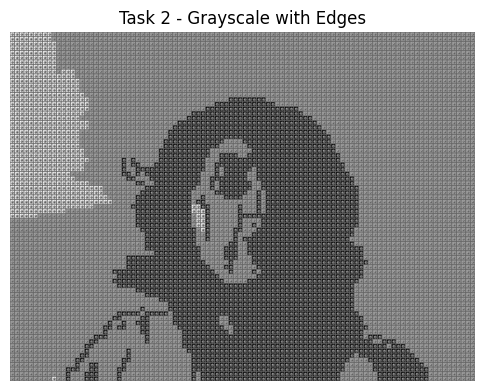

In [15]:
# TASK 2: 3 colored grayscale LEGO

lego_img = resize_for_lego(img)

# converting to grayscale
gray = to_grayscale(lego_img)

# reduces webcam noise before quantization
gray = cv2.GaussianBlur(gray, (3, 3), 0)

# adding edge detection
edges = cv2.Canny(gray, 100, 200)

# quantizing the grayscale
lego_gray = quantize_3_colors(gray)

# overlaying the edges which forces them to be black color
lego_gray[edges > 0] = 0

# convert to RGB
lego_rendered = render_lego(lego_gray)

# upscaling the bricks so they look like LEGO
lego_big = upscale_lego(lego_rendered, brick_size=10)

# adding the LEGO style render
lego_styled_t2 = render_lego_style(lego_big, brick_size=10)

plt.figure(figsize=(6,6))
plt.imshow(lego_styled_t2)
plt.axis("off")
plt.title("Task 2 - Grayscale with Edges")
plt.show()

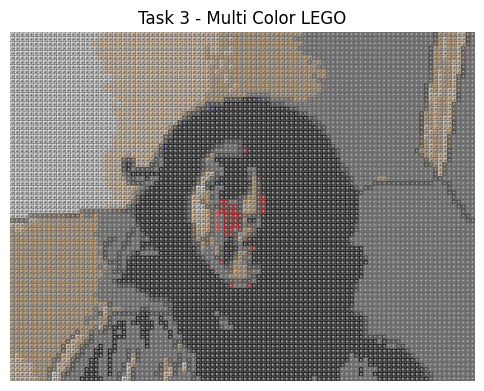


Brick Summary:
2x4: 589
2x2: 286
1x2: 321
1x1: 1002
Total bricks: 2198


In [16]:
# TASK 3: Multi-Color + Multi-Brick LEGO

# LEGO COLOR PALETTE
LEGO_COLORS = np.array([
    # Neutrals
    [0, 0, 0],
    [120, 120, 120],
    [255, 255, 255],

    # Blues
    [0, 0, 120],
    [0, 0, 200],
    [30, 90, 180],
    [50, 150, 255],

    # Cyan / Turquoise
    [0, 150, 200],
    [0, 200, 220],
    [50, 220, 220],

    # Greens
    [0, 150, 0],
    [0, 200, 0],
    [80, 255, 80],

    # Skin tones
    [255, 200, 150],
    [255, 220, 180],
    [210, 170, 120],

    # Reds / Oranges
    [180, 0, 0],
    [255, 80, 80],
    [255, 140, 0],
])


# Color Quantization
def quantize_to_lego_palette(img):
    h, w, _ = img.shape
    reshaped = img.reshape(-1, 3)

    quantized = []

    for pixel in reshaped:
        distances = np.linalg.norm(LEGO_COLORS - pixel, axis=1)
        nearest = LEGO_COLORS[np.argmin(distances)]
        quantized.append(nearest)

    quantized = np.array(quantized).reshape(h, w, 3)
    return quantized.astype(np.uint8)


# Multi-Brick Layout Generator
def generate_brick_layout(grid):
    h, w, _ = grid.shape
    used = np.zeros((h, w), dtype=bool)
    brick_grid = np.zeros_like(grid)

    brick_counts = {
        "2x4": 0,
        "2x2": 0,
        "1x2": 0,
        "1x1": 0
    }

    for y in range(h):
        for x in range(w):

            if used[y, x]:
                continue

            color = grid[y, x]

            # 2x4
            if y+1 < h and x+3 < w:
                block = grid[y:y+2, x:x+4]
                if (not used[y:y+2, x:x+4].any()) and np.all(block == color):
                    used[y:y+2, x:x+4] = True
                    brick_grid[y:y+2, x:x+4] = color
                    brick_counts["2x4"] += 1
                    continue

            # 2x2
            if y+1 < h and x+1 < w:
                block = grid[y:y+2, x:x+2]
                if (not used[y:y+2, x:x+2].any()) and np.all(block == color):
                    used[y:y+2, x:x+2] = True
                    brick_grid[y:y+2, x:x+2] = color
                    brick_counts["2x2"] += 1
                    continue

            # 1x2 horizontal
            if x+1 < w:
                block = grid[y, x:x+2]
                if (not used[y, x:x+2].any()) and np.all(block == color):
                    used[y, x:x+2] = True
                    brick_grid[y, x:x+2] = color
                    brick_counts["1x2"] += 1
                    continue

            # 1x1
            used[y, x] = True
            brick_grid[y, x] = color
            brick_counts["1x1"] += 1

    return brick_grid, brick_counts

# RUN PIPELINE

lego_img_t3 = resize_for_lego(img)

# Contrast + Saturation Enhancement
hsv = cv2.cvtColor(lego_img_t3, cv2.COLOR_RGB2HSV)

hsv[:,:,1] = np.clip(hsv[:,:,1] * 1.8, 0, 255)  # stronger saturation
hsv[:,:,2] = cv2.equalizeHist(hsv[:,:,2])       # improve contrast

lego_img_t3 = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# Quantize Colors
lego_quantized = quantize_to_lego_palette(lego_img_t3)

# Edge Reinforcement AFTER Quantization
gray_edges = cv2.cvtColor(lego_img_t3, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray_edges, 120, 250)

kernel = np.ones((1,1), np.uint8)
edges = cv2.dilate(edges, kernel, iterations=1)

lego_quantized[edges > 0] = (lego_quantized[edges > 0] * 0.5).astype(np.uint8)

# Multi-Brick Merge
brick_layout, brick_counts = generate_brick_layout(lego_quantized)

# LEGO Render
lego_big_t3 = upscale_lego(brick_layout, 12)
lego_styled_t3 = render_lego_style(lego_big_t3, 12)

plt.figure(figsize=(6,6))
plt.imshow(lego_styled_t3)
plt.axis("off")
plt.title("Task 3 - Multi Color LEGO")
plt.show()

# Brick Summary
print("\nBrick Summary:")
for k, v in brick_counts.items():
    print(f"{k}: {v}")

print("Total bricks:", sum(brick_counts.values()))


In [17]:
# Save Task 2 output
cv2.imwrite(
    "lego_task2_output.png",
    cv2.cvtColor(lego_styled_t2, cv2.COLOR_RGB2BGR)
)

# Save Task 3 output
cv2.imwrite(
    "lego_task3_output.png",
    cv2.cvtColor(lego_styled_t3, cv2.COLOR_RGB2BGR)
)

print("Images saved successfully.")

Images saved successfully.
